# Stroke prediction - Reference results recreation

## Imports and constants

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


scaler = StandardScaler()

## Dataset analysis

In [ ]:
df = pd.read_csv("data/health-dataset/stroke_data.csv")
display(df.head(5))

,sex,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,63.0,0,1,1,4,1,228.69,36.6,1,1
1,1.0,42.0,0,1,1,4,0,105.92,32.5,0,1
2,0.0,61.0,0,0,1,4,1,171.23,34.4,1,1
3,1.0,41.0,1,0,1,3,0,174.12,24.0,0,1
4,1.0,85.0,0,0,1,4,1,186.21,29.0,1,1


In [ ]:
display(pd.DataFrame({"sum": df.isnull().sum(), "unique": df.nunique()}))

,sum,unique
sex,3,2
age,0,111
hypertension,0,2
heart_disease,0,2
ever_married,0,2
work_type,0,5
Residence_type,0,2
avg_glucose_level,0,2903
bmi,0,370
smoking_status,0,2


In [ ]:
display(df.describe())

,sex,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,40907.000000,40910.000000,40910.000000,40910.000000,40910.000000,40910.000000,40910.000000,40910.000000,40910.000000,40910.000000,40910.000000
mean,0.555162,51.327255,0.213835,0.127719,0.821340,3.461134,0.514886,122.075901,30.406355,0.488609,0.500122
std,0.496954,21.623969,0.410017,0.333781,0.383072,0.780919,0.499784,57.561531,6.835072,0.499876,0.500006
min,0.000000,-9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.120000,11.500000,0.000000,0.000000
25%,0.000000,35.000000,0.000000,0.000000,1.000000,3.000000,0.000000,78.750000,25.900000,0.000000,0.000000
50%,1.000000,52.000000,0.000000,0.000000,1.000000,4.000000,1.000000,97.920000,29.400000,0.000000,1.000000
75%,1.000000,68.000000,0.000000,0.000000,1.000000,4.000000,1.000000,167.590000,34.100000,1.000000,1.000000
max,1.000000,103.000000,1.000000,1.000000,1.000000,4.000000,1.000000,271.740000,92.000000,1.000000,1.000000


stroke
1    20460
0    20450
Name: count, dtype: int64


<Axes: xlabel='stroke', ylabel='count'>

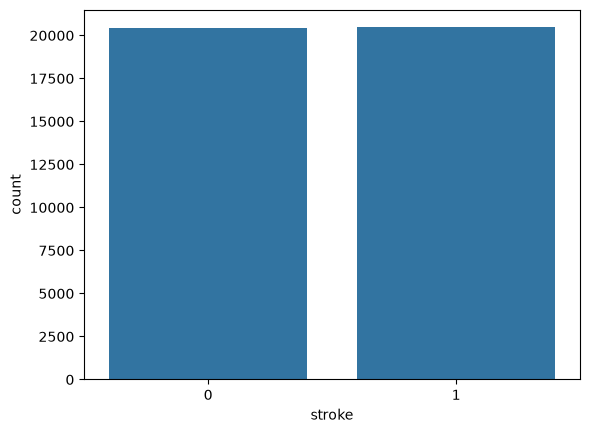

In [ ]:
print(df['stroke'].value_counts())
sns.countplot(x='stroke', data=df)

## Preprocessing

<Axes: >

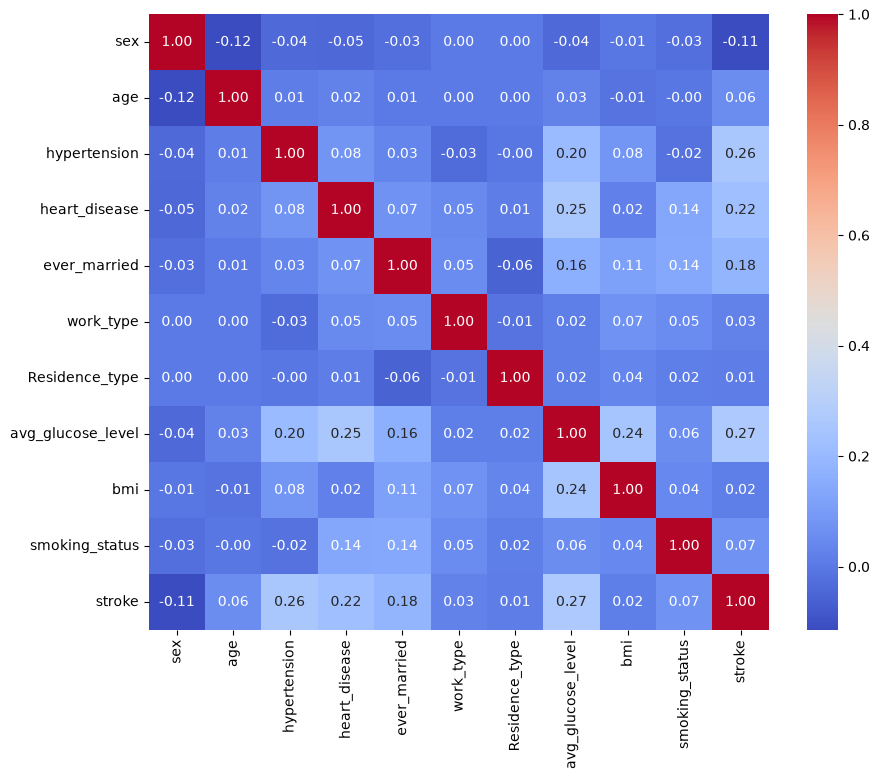

In [ ]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

<Axes: >

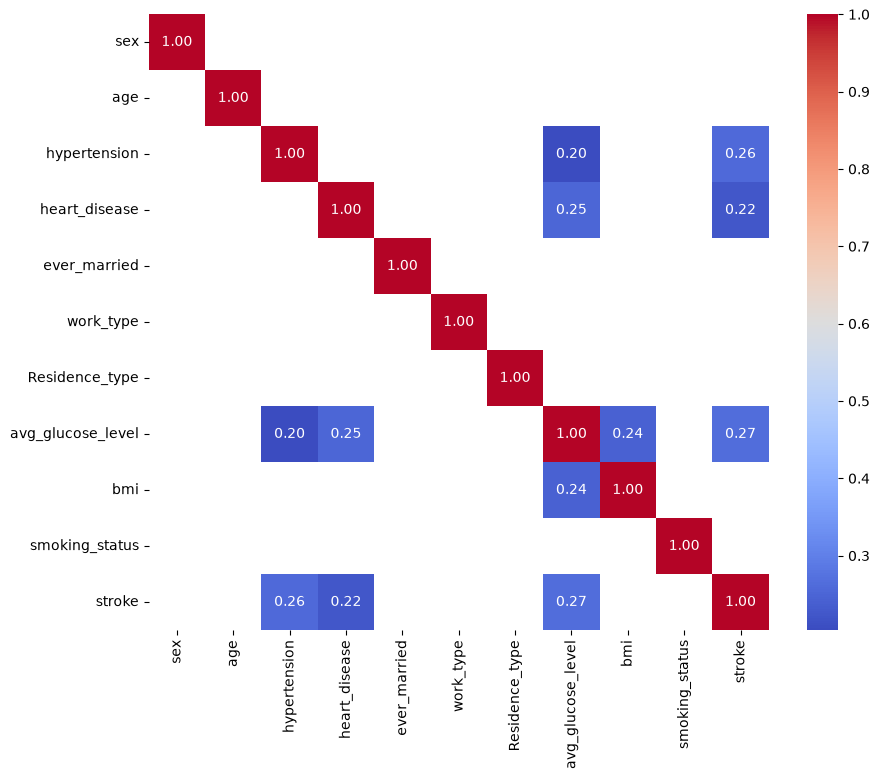

In [ ]:
threshold = 0.2
plt.figure(figsize=(10, 8))
sns.heatmap(corr[(abs(corr) > threshold) | (abs(corr) < -1 * threshold)], annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
corr_stroke = corr['stroke']
insignificant_corr_indexes = corr_stroke[(corr_stroke > -0.2) & (corr_stroke < 0.2)].index.tolist()
display(insignificant_corr_indexes)


['sex',
 'age',
 'ever_married',
 'work_type',
 'Residence_type',
 'bmi',
 'smoking_status']

In [ ]:
df.drop(columns=insignificant_corr_indexes, inplace=True)
display(df.head(5))

,hypertension,heart_disease,avg_glucose_level,stroke
0,0,1,228.69,1
1,0,1,105.92,1
2,0,0,171.23,1
3,1,0,174.12,1
4,0,0,186.21,1


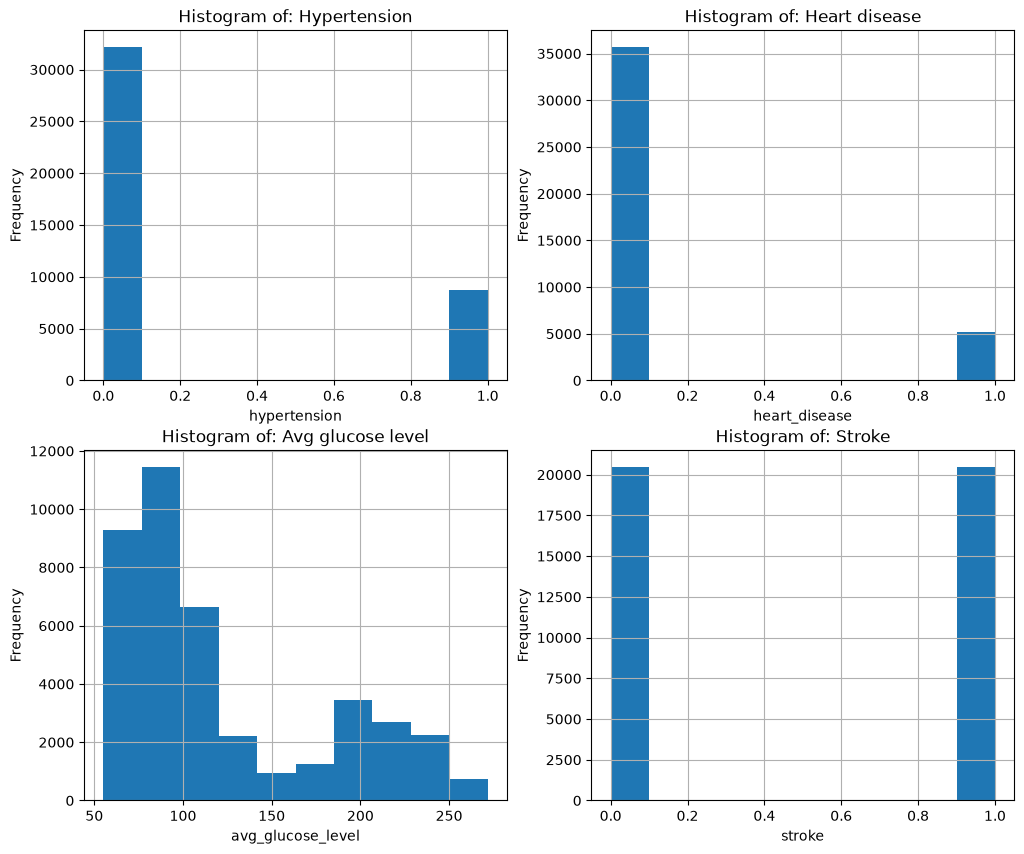

In [ ]:
for col in df.columns:
    plt.subplot(2, 2, list(df.columns).index(col) + 1)
    df[col].hist()
    plt.title(f"Histogram of: {col.replace('_', ' ').capitalize()}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.gcf().set_size_inches(12, 10)
plt.show()

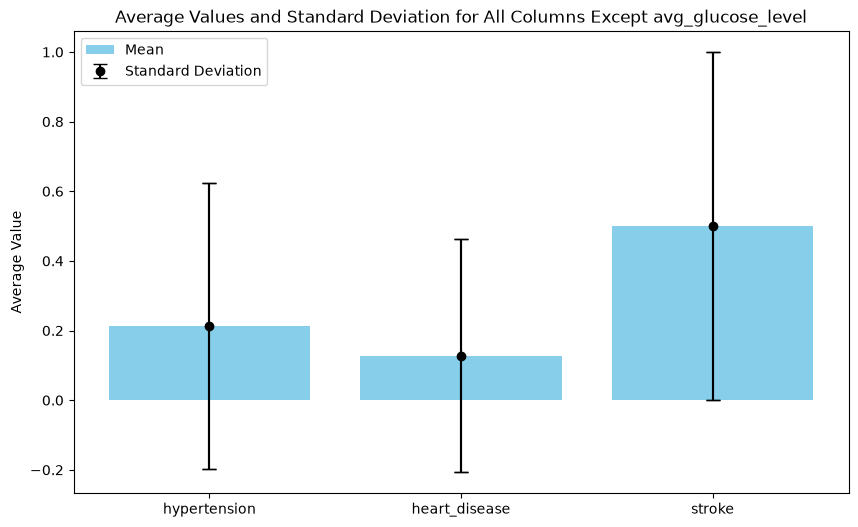

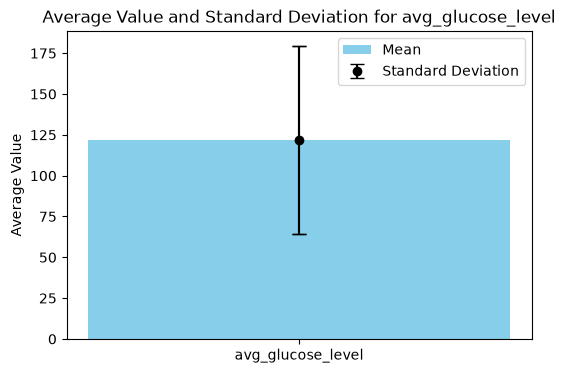

In [ ]:
means_all = df.drop(columns=['avg_glucose_level']).mean()
stds_all = df.drop(columns=['avg_glucose_level']).std()
means_glucose = df['avg_glucose_level'].mean()
stds_glucose = df['avg_glucose_level'].std()

plt.figure(figsize=(10, 6))
plt.bar(means_all.index, means_all, yerr=stds_all, capsize=5, color='skyblue')
plt.errorbar(means_all.index, means_all, yerr=stds_all, fmt='o', color='black', capsize=5)
plt.ylabel('Average Value')
plt.title('Average Values and Standard Deviation for All Columns Except avg_glucose_level')
plt.legend(['Mean', 'Standard Deviation'])
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(['avg_glucose_level'], [means_glucose], yerr=[stds_glucose], capsize=5, color='skyblue')
plt.errorbar(['avg_glucose_level'], [means_glucose], yerr=[stds_glucose], fmt='o', color='black', capsize=5)
plt.ylabel('Average Value')
plt.title('Average Value and Standard Deviation for avg_glucose_level')
plt.legend(['Mean', 'Standard Deviation'])
plt.show()

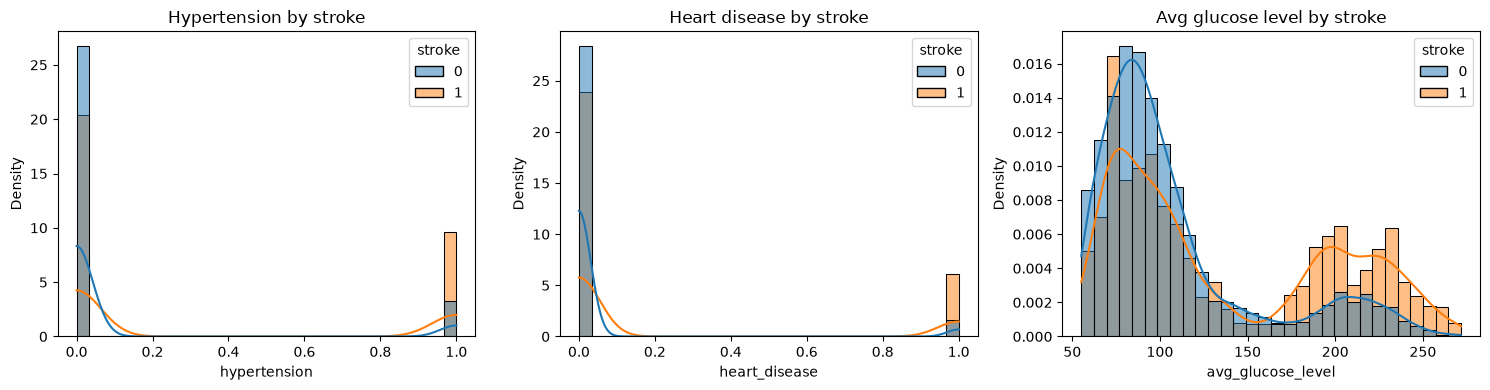

In [ ]:
feature_cols = [c for c in df.columns if c != 'stroke']
n_cols = 3
n_rows = -(-len(feature_cols) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, hue='stroke', stat='density', common_norm=False,
                 kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"{col.replace('_', ' ').capitalize()} by stroke")

# hide any unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Data processing

In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

### Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123123, stratify=y
)

In [ ]:
print('Total dataset size:', X.shape[0])
print('Training set size:', X_train.shape[0], '({:.2f}%)'.format(X_train.shape[0] / X.shape[0] * 100))
print('Test set size:', X_test.shape[0], '({:.2f}%)'.format(X_test.shape[0] / X.shape[0] * 100))

Total dataset size: 40910
Training set size: 32728 (80.00%)
Test set size: 8182 (20.00%)


### Standardization

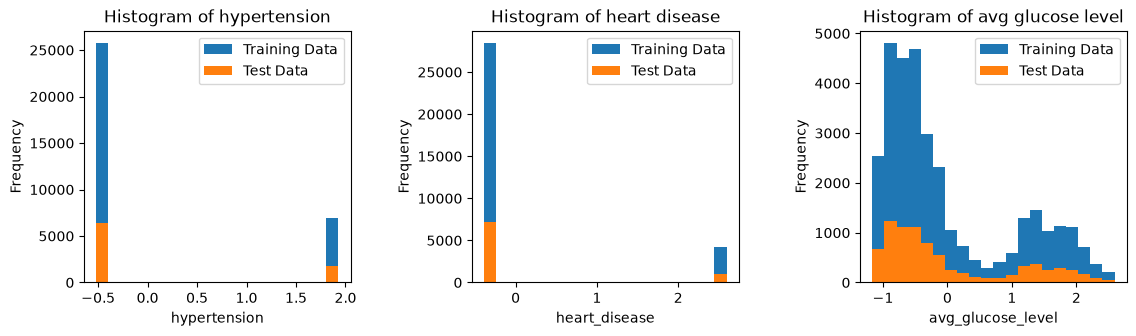

Mean of scaled training data:
 [-0. -0.  0.]
Standard deviation of scaled training data:
 [1. 1. 1.]


In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for col in range(X_test.shape[1]):
    ax_col = col % 3
    ax[ax_col].hist(X_train_scaled[:, col], bins=20)
    ax[ax_col].hist(X_test_scaled[:, col], bins=20)
    ax[ax_col].set_title(f"Histogram of {X_test.columns[col].replace('_', ' ')}")
    ax[ax_col].set_xlabel(X_test.columns[col])
    ax[ax_col].set_ylabel('Frequency')
    ax[ax_col].legend(['Training Data', 'Test Data'])
plt.tight_layout(pad=3.0)
plt.show()

X_train_scaled_mean = X_train_scaled.mean(axis=0)
X_train_scaled_std = X_train_scaled.std(axis=0)
print("Mean of scaled training data:\n", np.round(X_train_scaled_mean, 15))
print("Standard deviation of scaled training data:\n", np.round(X_train_scaled_std, 15))

## Logistic regression model

In [ ]:
log_reg = LogisticRegression(
    max_iter=20000
)


### Grid search

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123123)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=5000, random_state=123123))
])

param_grid = [
    {
        "log_reg__C": np.logspace(-3, 3, 15),
        "log_reg__solver": ["lbfgs"],
        "log_reg__penalty": ["l2"],
        "log_reg__class_weight": [None, "balanced"]
    },
    {
        "log_reg__C": np.logspace(-3, 3, 15),
        "log_reg__solver": ["liblinear"],
        "log_reg__penalty": ["l1", "l2"],
        "log_reg__class_weight": [None, "balanced"]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid_search.fit(X_train, y_train)
print("Best cross-validation ROC-AUC:", grid_search.best_score_)
print("Best hyperparameters:", grid_search.best_params_)


Best cross-validation ROC-AUC: 0.7039533676584968
Best hyperparameters: {'log_reg__C': np.float64(7.196856730011514), 'log_reg__class_weight': None, 'log_reg__penalty': 'l2', 'log_reg__solver': 'liblinear'}


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

log_reg = best_model
print("Chosen model: Logistic Regression")
print("Final selected hyperparameters:", grid_search.best_params_)


Test ROC-AUC: 0.6986031842201493
Test accuracy: 0.6759960889758005
              precision    recall  f1-score   support

   No stroke       0.65      0.77      0.70      4090
      Stroke       0.72      0.58      0.64      4092

    accuracy                           0.68      8182
   macro avg       0.68      0.68      0.67      8182
weighted avg       0.68      0.68      0.67      8182

Chosen model: Logistic Regression
Final selected hyperparameters: {'log_reg__C': np.float64(7.196856730011514), 'log_reg__class_weight': None, 'log_reg__penalty': 'l2', 'log_reg__solver': 'liblinear'}


### Prediction and model evaluation

Test ROC-AUC: 0.6986031842201493
Test accuracy: 0.6759960889758005
              precision    recall  f1-score   support

   No stroke       0.65      0.77      0.70      4090
      Stroke       0.72      0.58      0.64      4092

    accuracy                           0.68      8182
   macro avg       0.68      0.68      0.67      8182
weighted avg       0.68      0.68      0.67      8182



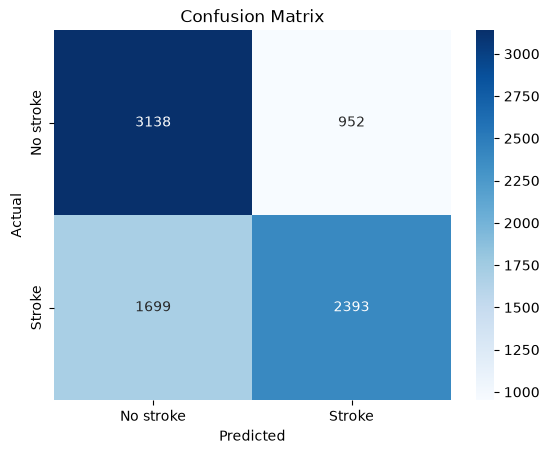

In [ ]:
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Decision tree model

In [ ]:
dt_model = DecisionTreeClassifier(random_state=123123)

Test ROC-AUC: 0.9995913369040194
Test accuracy: 0.9971889513566365
              precision    recall  f1-score   support

   No stroke       1.00      0.99      1.00      4090
      Stroke       0.99      1.00      1.00      4092

    accuracy                           1.00      8182
   macro avg       1.00      1.00      1.00      8182
weighted avg       1.00      1.00      1.00      8182



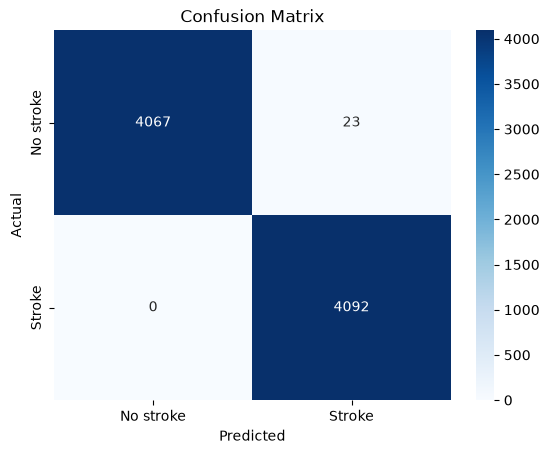

In [ ]:
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature importances:
avg_glucose_level    0.922618
hypertension         0.046689
heart_disease        0.030694
dtype: float64


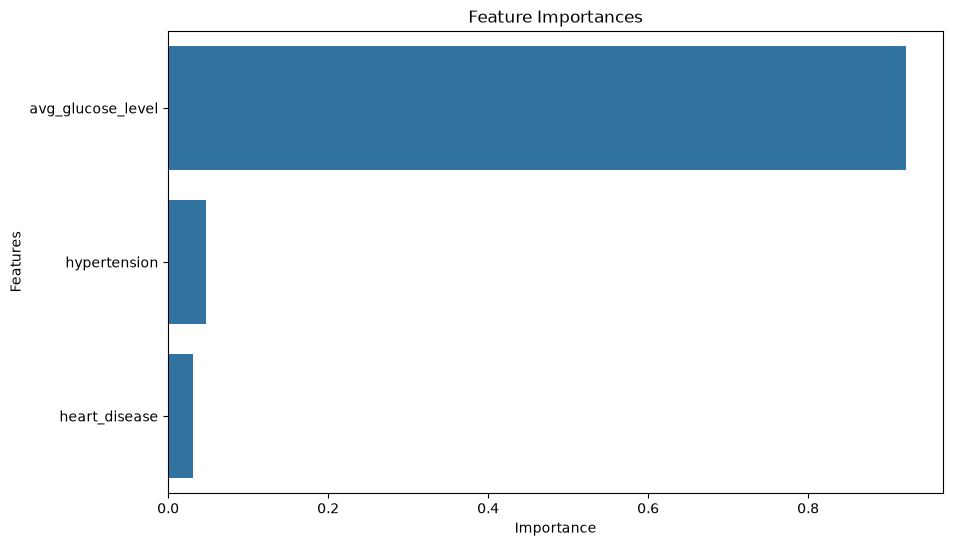

In [ ]:
feature_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print("Feature importances:")
print(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importances")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.show()

## Random forest model

In [ ]:
rf_model = RandomForestClassifier(random_state=123123)

Test ROC-AUC: 0.9995898431431597
Test accuracy: 0.9971889513566365
              precision    recall  f1-score   support

   No stroke       1.00      0.99      1.00      4090
      Stroke       0.99      1.00      1.00      4092

    accuracy                           1.00      8182
   macro avg       1.00      1.00      1.00      8182
weighted avg       1.00      1.00      1.00      8182



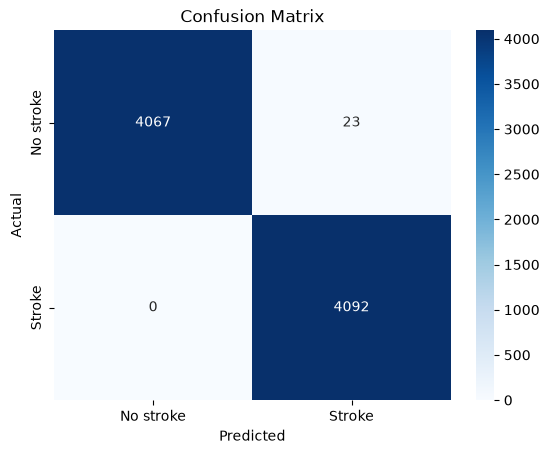

In [ ]:
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature importances:
avg_glucose_level    0.901789
hypertension         0.055997
heart_disease        0.042214
dtype: float64


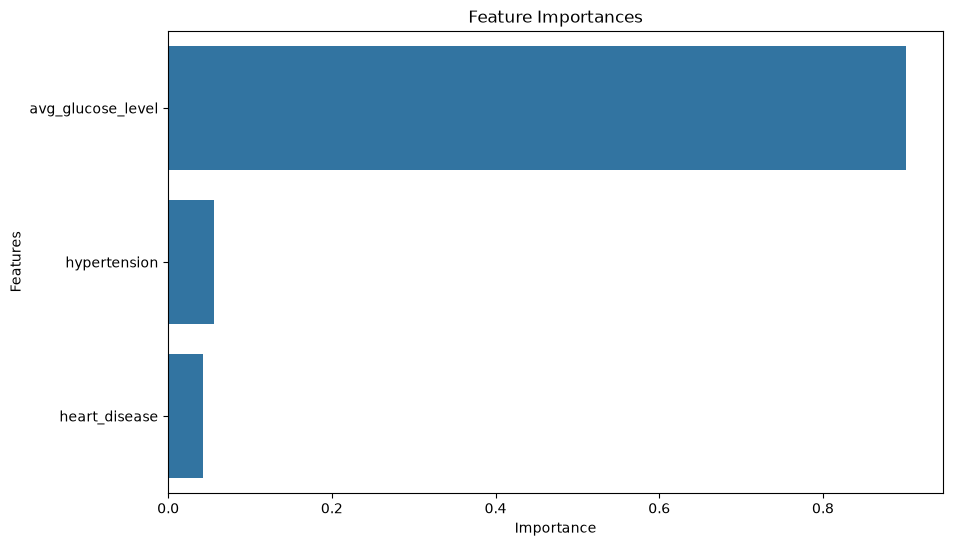

In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print("Feature importances:")
print(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importances")
plt.ylabel("Features")
plt.xlabel("Importance")
plt.show()

## K-Nearest neighbors model

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [ ]:
param_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(knn_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
knn_model = grid_search.best_estimator_
print("Best KNN model:", knn_model)

Best KNN model: KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='distance')


Test ROC-AUC: 0.9978966652087561
Test accuracy: 0.9971889513566365
              precision    recall  f1-score   support

   No stroke       1.00      0.99      1.00      4090
      Stroke       0.99      1.00      1.00      4092

    accuracy                           1.00      8182
   macro avg       1.00      1.00      1.00      8182
weighted avg       1.00      1.00      1.00      8182



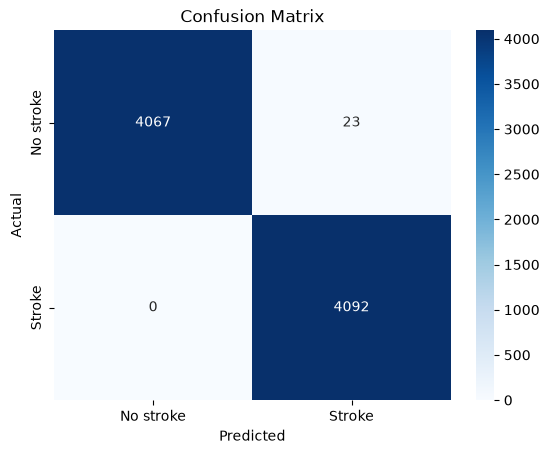

In [ ]:
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
y_proba = knn_model.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred, target_names=["No stroke", "Stroke"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Duplicates analysis

In [ ]:
train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

merged = test_df.merge(train_df.drop_duplicates(), how='left', indicator=True)
duplicate_mask = merged['_merge'] == 'both'

duplicate_rows = test_df[duplicate_mask]
n_duplicates = duplicate_mask.sum()
pct_duplicates = n_duplicates / len(test_df) * 100

print("Number of rows in test:", len(test_df))
print(f"Number of test rows duplicated in train: {n_duplicates}")
print(f"Percentage of test set: {pct_duplicates:.2f}%")

Number of rows in test: 8182
Number of test rows duplicated in train: 8177
Percentage of test set: 99.94%


In [ ]:
print("Shape of the dataframe before removing duplicates:", df.shape)
df_copy = df.copy()
df_copy.drop_duplicates(inplace=True)
print("Shape of the dataframe after removing duplicates:", df_copy.shape)

Shape of the dataframe before removing duplicates: (40910, 4)
Shape of the dataframe after removing duplicates: (3033, 4)


array([[<Axes: title={'center': 'hypertension'}>,
        <Axes: title={'center': 'heart_disease'}>],
       [<Axes: title={'center': 'avg_glucose_level'}>,
        <Axes: title={'center': 'stroke'}>]], dtype=object)

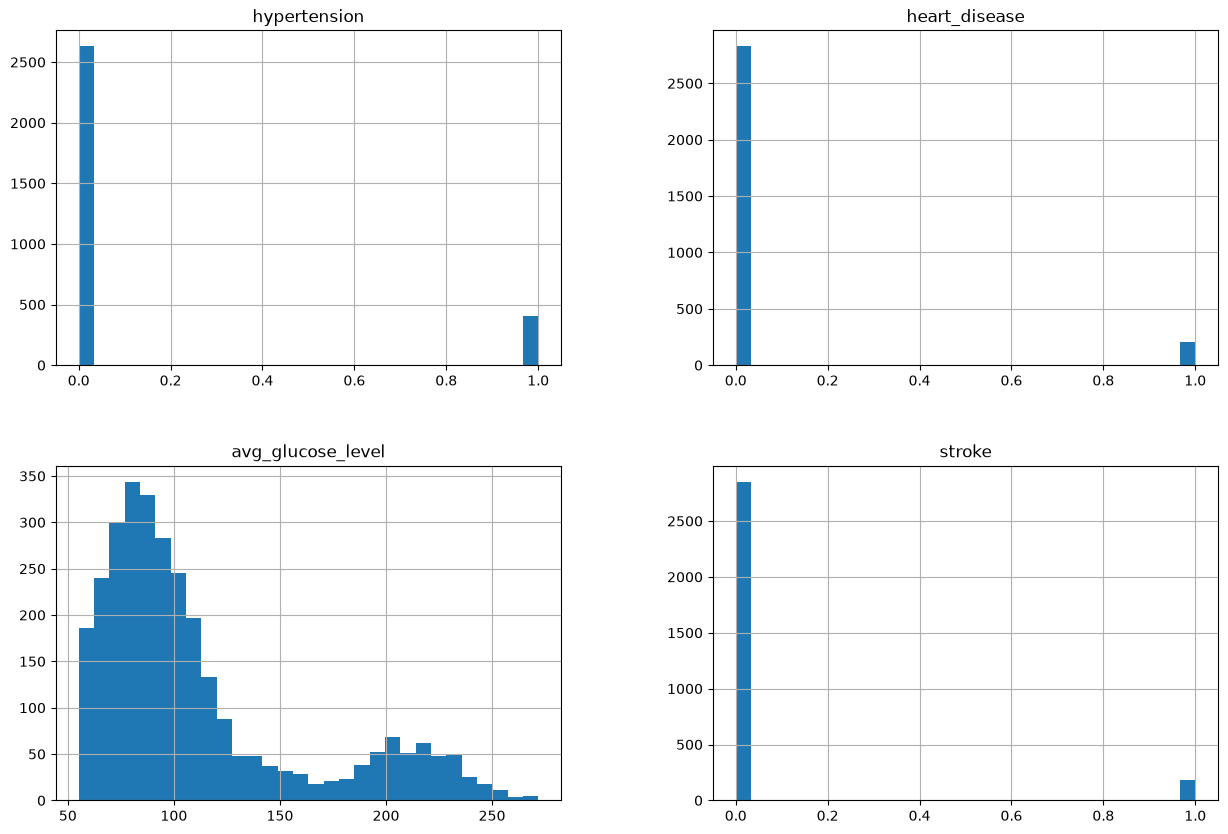

In [ ]:
df_copy.hist(bins=30, figsize=(15, 10))

In [ ]:
feature_cols = [c for c in df.columns if c != 'stroke']

conflict_groups = df.groupby(feature_cols)['stroke'].nunique()
conflicting_feature_sets = conflict_groups[conflict_groups > 1].index

conflicting_rows = df.merge(pd.DataFrame(conflicting_feature_sets.tolist(), columns=feature_cols),
                             on=feature_cols, how='inner')

n_conflicting = len(conflicting_rows)
pct_conflicting = n_conflicting / len(df) * 100

print("Number of distinct feature-sets with conflicting stroke labels:", len(conflicting_feature_sets))
print(f"Number of rows involved in a conflict: {n_conflicting}")
print(f"Percentage of dataset: {pct_conflicting:.2f}%")

stroke_counts_in_conflicts = conflicting_rows['stroke'].value_counts()
print("Stroke value counts among conflicting rows:")
print(stroke_counts_in_conflicts)

Number of distinct feature-sets with conflicting stroke labels: 21
Number of rows involved in a conflict: 2512
Percentage of dataset: 6.14%
Stroke value counts among conflicting rows:
stroke
1    2378
0     134
Name: count, dtype: int64


In [ ]:
train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
badly_classified = pd.DataFrame(
    X_test_scaled[y_test != y_pred], columns=X_test.columns
)

merged = badly_classified.merge(train_df.drop_duplicates(), how='left', indicator=True)
duplicate_mask = merged['_merge'] == 'both'

duplicate_rows = badly_classified[duplicate_mask]
n_duplicates = duplicate_mask.sum()
pct_duplicates = n_duplicates / len(badly_classified) * 100

print("Number of badly classified rows:", len(badly_classified))
print(f"Number of badly classified rows duplicated in train: {n_duplicates}")
print(f"Percentage of badly classified set: {pct_duplicates:.2f}%")

Number of badly classified rows: 23
Number of badly classified rows duplicated in train: 23
Percentage of badly classified set: 100.00%


Text(0.5, 0.98, 'Histograms of Badly Classified Rows')

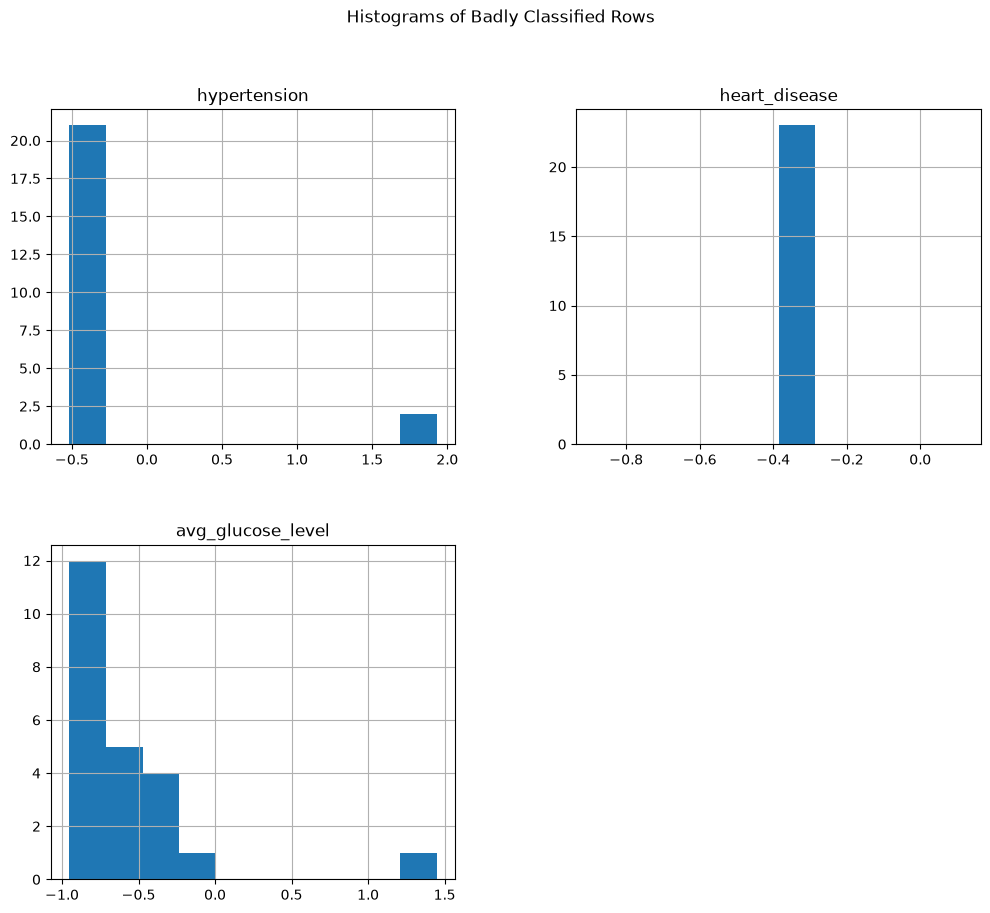

In [ ]:
badly_classified.hist(figsize=(12, 10))
plt.suptitle("Histograms of Badly Classified Rows")


In [ ]:
badly_classified_unscaled = pd.DataFrame(
    scaler.inverse_transform(badly_classified), columns=feature_cols
)
badly_classified_unscaled['stroke'] = y_test[y_test != y_pred].values

merge_cols = feature_cols + ['stroke']
badly_rounded = badly_classified_unscaled.round(6)
conflicting_rounded = conflicting_rows.round(6)

merged_badly = badly_rounded.merge(conflicting_rounded[merge_cols].drop_duplicates(),
                                    on=merge_cols, how='left', indicator=True)
in_conflict_mask = merged_badly['_merge'] == 'both'

n_in_conflict = in_conflict_mask.sum()
pct_in_conflict = n_in_conflict / len(badly_classified_unscaled) * 100

print("Number of badly classified rows:", len(badly_classified_unscaled))
print(f"Number of badly classified rows present in conflicting rows: {n_in_conflict}")
print(f"Percentage of badly classified set: {pct_in_conflict:.2f}%")

Number of badly classified rows: 23
Number of badly classified rows present in conflicting rows: 23
Percentage of badly classified set: 100.00%
